# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
df = pd.read_csv('../StudentPerformanceFactors_raw.csv')

selected_columns = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement', 
    'Access_to_Resources', 'Extracurricular_Activities', 
    'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 
    'Internet_Access', 'Tutoring_Sessions', 
    'Exam_Score'
]

try:
    df = df[selected_columns]
    print("Dataset berhasil dimuat dan difilter!")
    display(df.head())
except KeyError as e:
    print(f"Error: Ada nama kolom yang tidak cocok dengan dataset asli. Cek kembali: {e}")

Dataset berhasil dimuat dan difilter!


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,70


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Exam_Score                  6607 non-null   int64 
dtypes: int64(6), object(5)
memory usage: 567.9+ KB


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,101.000000


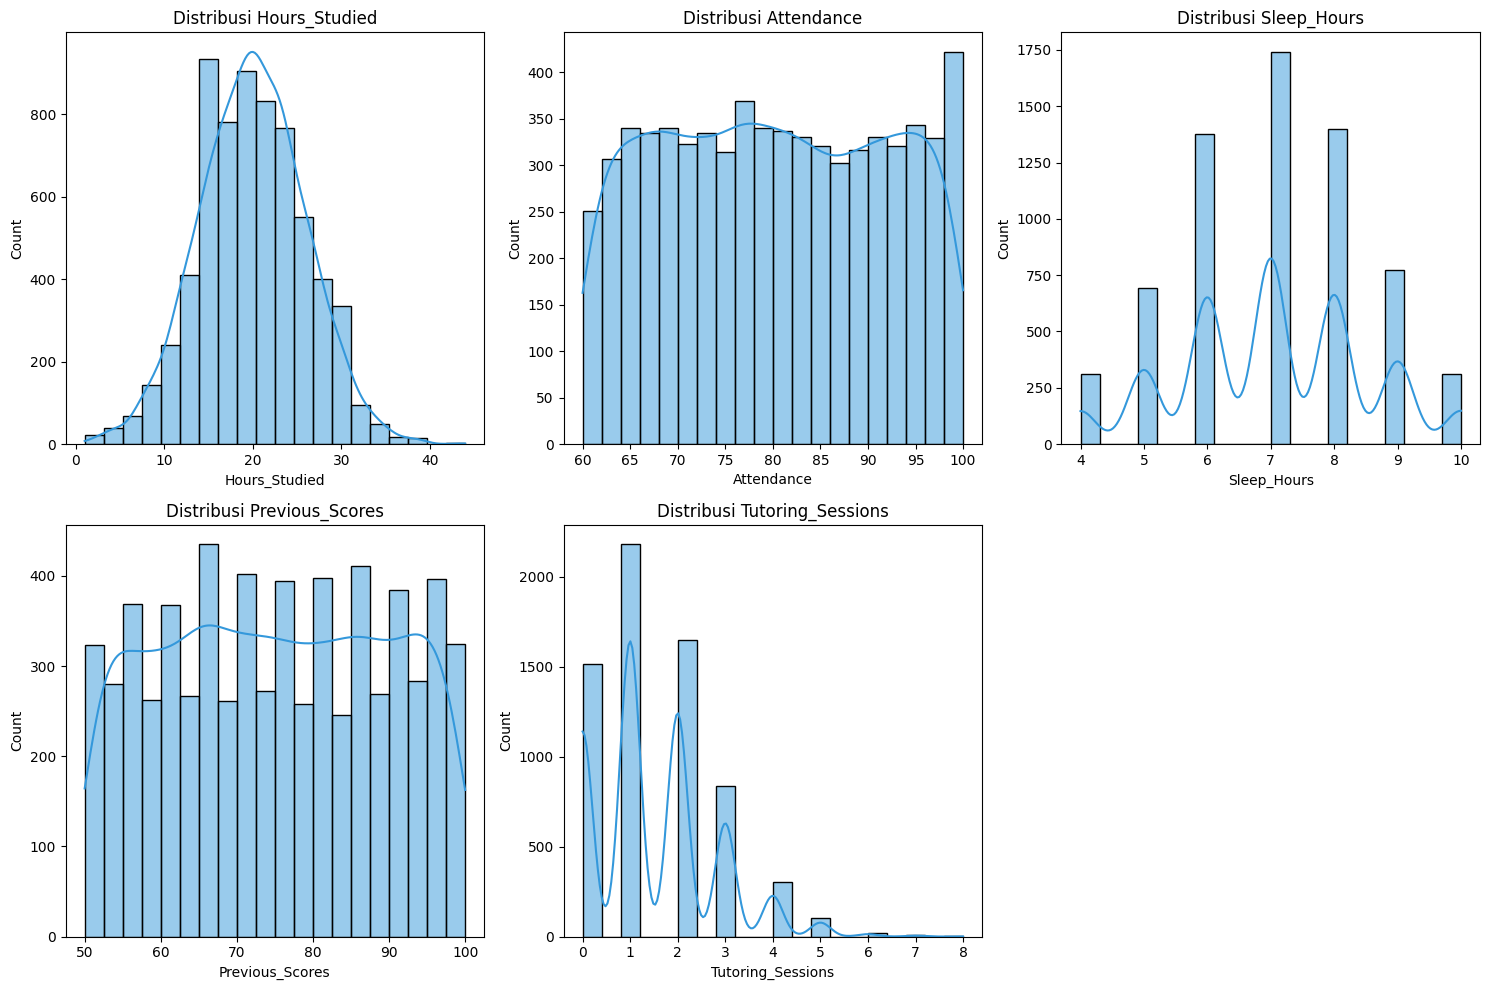

C:\Users\62812\AppData\Local\Temp\ipykernel_44972\1950756006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\62812\AppData\Local\Temp\ipykernel_44972\1950756006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\62812\AppData\Local\Temp\ipykernel_44972\1950756006.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
C:\Users\62812\AppData\Local\Temp\ipykernel_44972\1950756006.py:19: FutureWarning: 

Passing `

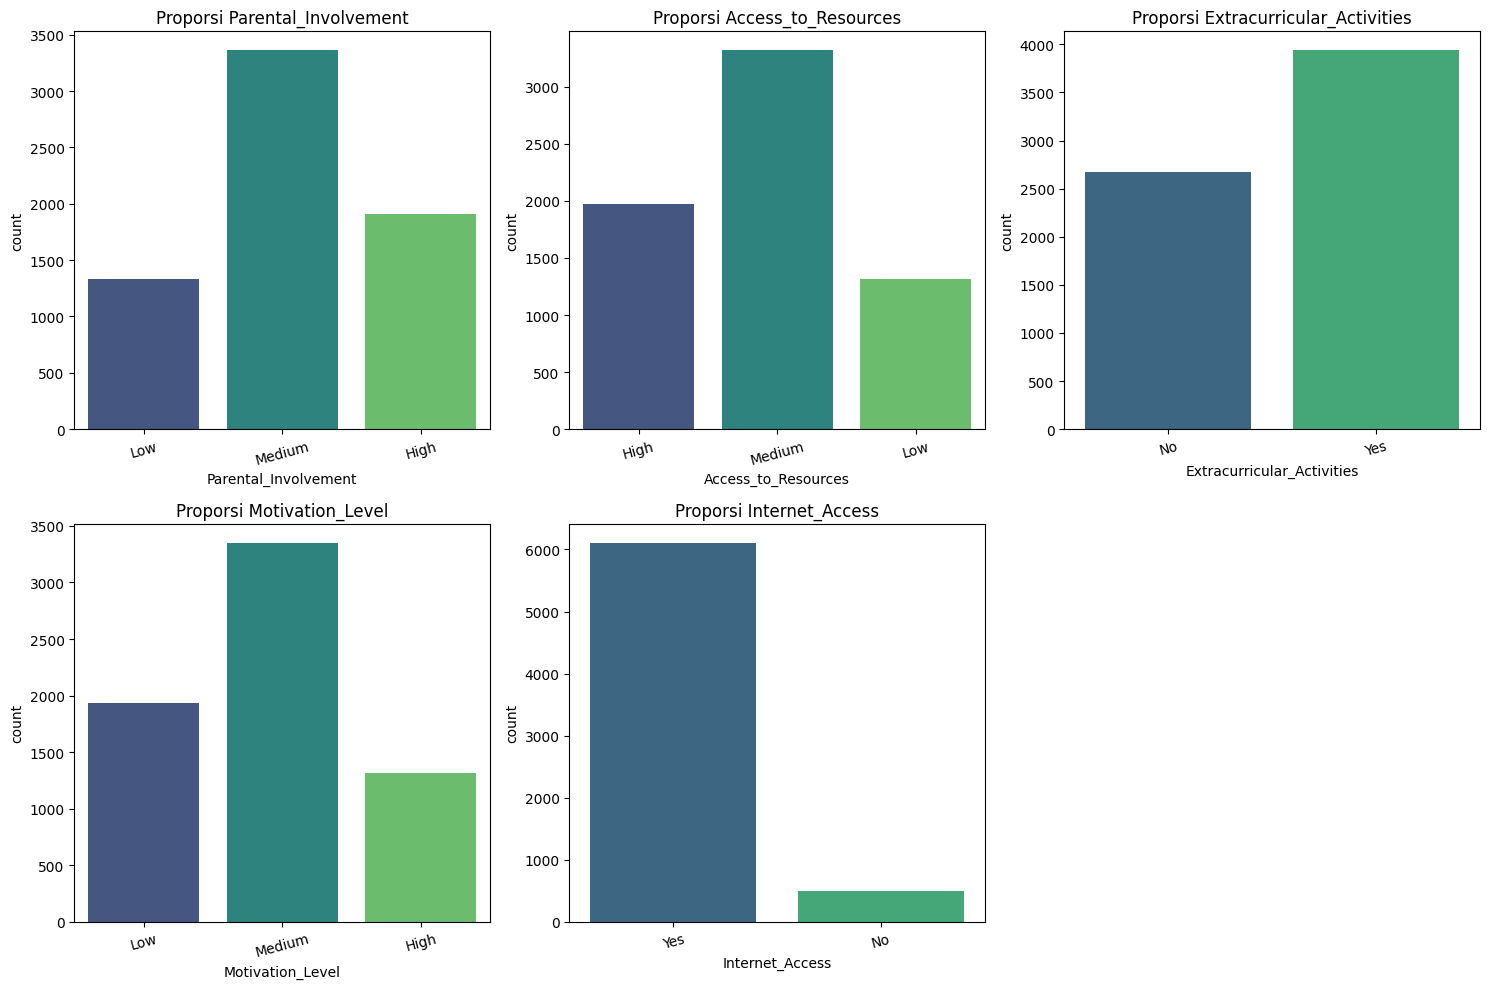

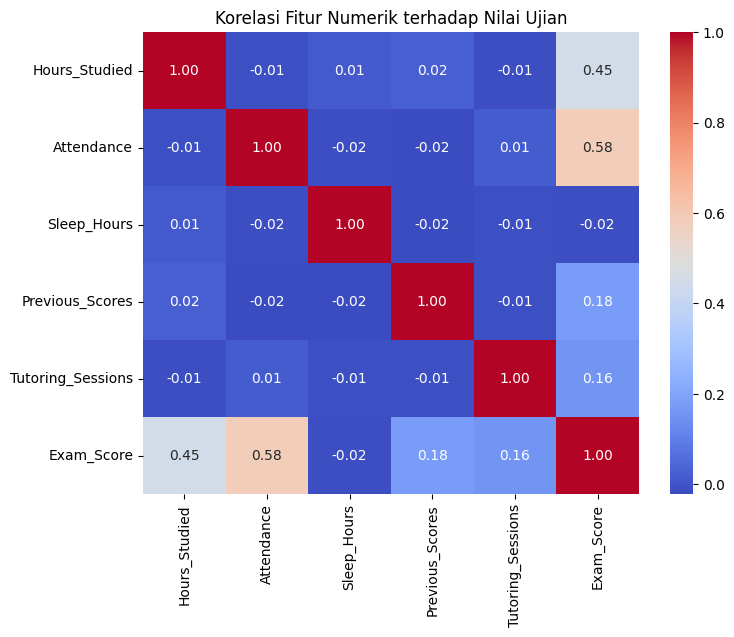

In [7]:
print("Informasi Dataset:\n")
df.info()
display(df.describe())

kolom_numerik = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions']
kolom_kategorikal = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access']

plt.figure(figsize=(15, 10))
for i, col in enumerate(kolom_numerik, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=20, color='#3498db')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(kolom_kategorikal, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Proporsi {col}')
    plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_numerik + ['Exam_Score']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Fitur Numerik terhadap Nilai Ujian")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
df_clean = df.copy()

print("Jumlah Missing Values sebelum diproses:")
print(df_clean.isnull().sum(), "\n")

imputer_num = SimpleImputer(strategy='mean')
df_clean[kolom_numerik] = imputer_num.fit_transform(df_clean[kolom_numerik])

imputer_cat = SimpleImputer(strategy='most_frequent')
df_clean[kolom_kategorikal] = imputer_cat.fit_transform(df_clean[kolom_kategorikal])

encoder = LabelEncoder()
for col in kolom_kategorikal:
    df_clean[col] = encoder.fit_transform(df_clean[col])
    print(f"Kolom '{col}' telah di-encode.")

scaler = StandardScaler()
df_clean[kolom_numerik] = scaler.fit_transform(df_clean[kolom_numerik])

output_path = 'StudentPerformanceFactors_preprocessing.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n[SUKSES] File berhasil disimpan ke: {output_path}")

print("\nDataset siap untuk pemodelan ML!")
display(df_clean.head())

Jumlah Missing Values sebelum diproses:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Exam_Score                    0
dtype: int64 

Kolom 'Parental_Involvement' telah di-encode.
Kolom 'Access_to_Resources' telah di-encode.
Kolom 'Extracurricular_Activities' telah di-encode.
Kolom 'Motivation_Level' telah di-encode.
Kolom 'Internet_Access' telah di-encode.

[SUKSES] File berhasil disimpan ke: StudentPerformanceFactors_preprocessing.csv

Dataset siap untuk pemodelan ML!


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Exam_Score
0,0.504942,0.348375,1,0,0,-0.019796,-0.143800,1,1,-1.213934,67
1,-0.162822,-1.383736,1,2,0,0.661399,-1.116110,1,1,0.411451,61
2,0.671882,1.560853,2,2,1,-0.019796,1.106313,2,1,0.411451,74
3,1.506587,0.781403,1,2,1,0.661399,1.592469,2,1,-0.401242,71
4,-0.162822,1.041220,2,2,1,-0.700990,-0.699406,2,1,1.224144,70
